In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data_dir = "dataset/train"

categories = ["cats", "dogs"]

print("Categories:", categories)

Categories: ['cats', 'dogs']


In [8]:
import pandas as pd

data = pd.read_csv("UniversalBank.csv")

data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [12]:
print(data.columns)

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')


In [14]:
data = data.drop(columns=['ID','ZIP Code'], errors='ignore')

data.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [15]:
X = data.drop("Personal Loan", axis=1)
y = data["Personal Loan"]

print(X.shape)
print(y.shape)

(5000, 11)
(5000,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
model = SVC(kernel='linear', C=10)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [19]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.953


In [21]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[889   6]
 [ 41  64]]


In [22]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       895
           1       0.91      0.61      0.73       105

    accuracy                           0.95      1000
   macro avg       0.94      0.80      0.85      1000
weighted avg       0.95      0.95      0.95      1000



In [23]:
model_rbf = SVC(kernel='rbf', C=10, gamma=0.1)

model_rbf.fit(X_train, y_train)

print("RBF Model trained")

RBF Model trained


In [24]:
y_pred_rbf = model_rbf.predict(X_test)

accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print("RBF Model Accuracy:", accuracy_rbf)

RBF Model Accuracy: 0.984


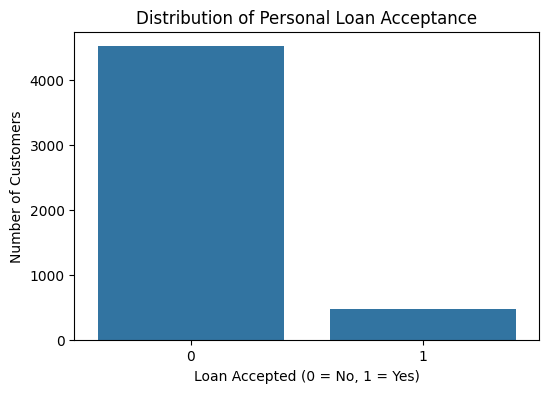

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Personal Loan', data=data)

plt.title("Distribution of Personal Loan Acceptance")
plt.xlabel("Loan Accepted (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

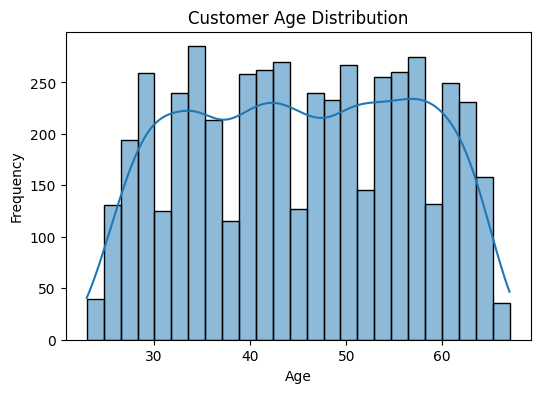

In [26]:
plt.figure(figsize=(6,4))

sns.histplot(data["Age"], bins=25, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

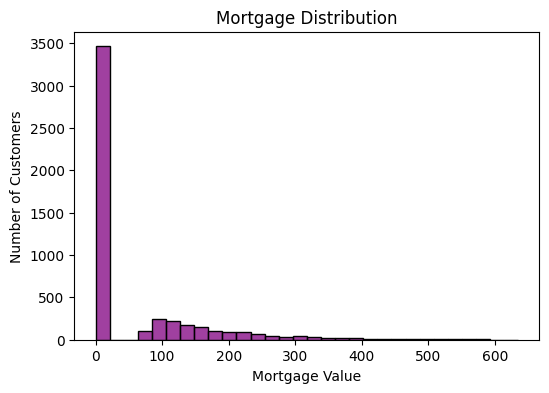

In [34]:
plt.figure(figsize=(6,4))

sns.histplot(data["Mortgage"], bins=30, color="purple")

plt.title("Mortgage Distribution")
plt.xlabel("Mortgage Value")
plt.ylabel("Number of Customers")

plt.show()

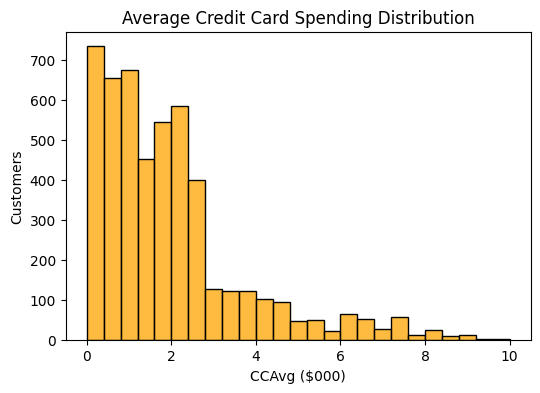

In [35]:
plt.figure(figsize=(6,4))

sns.histplot(data["CCAvg"], bins=25, color="orange")

plt.title("Average Credit Card Spending Distribution")
plt.xlabel("CCAvg ($000)")
plt.ylabel("Customers")

plt.show()

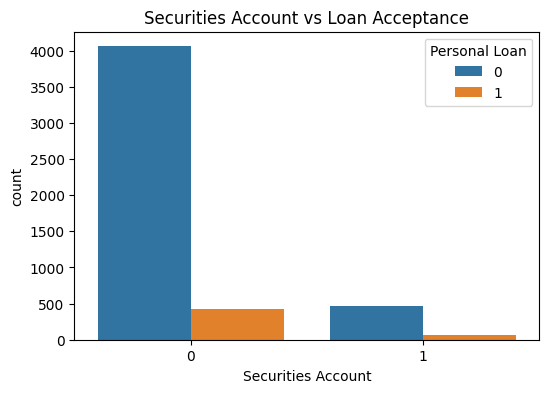

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(x="Securities Account", hue="Personal Loan", data=data)

plt.title("Securities Account vs Loan Acceptance")

plt.show()

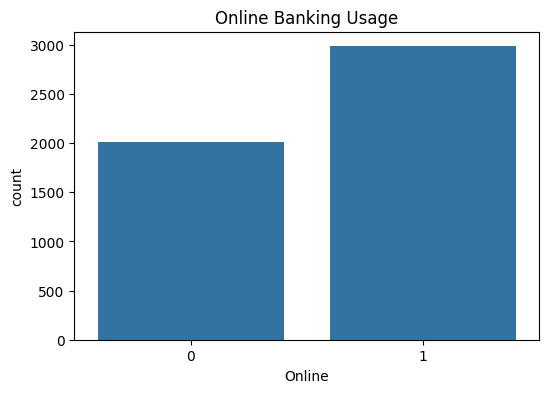

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(x="Online", data=data)

plt.title("Online Banking Usage")

plt.show()

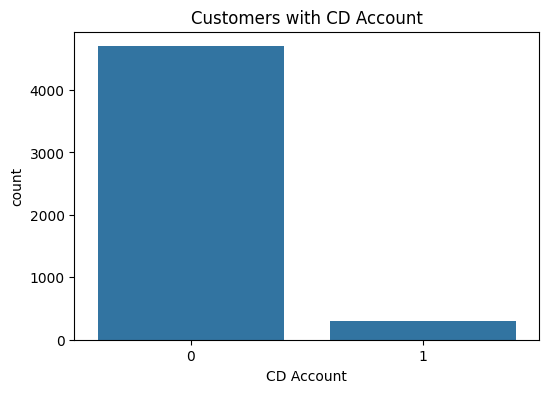

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(x="CD Account", data=data)

plt.title("Customers with CD Account")

plt.show()

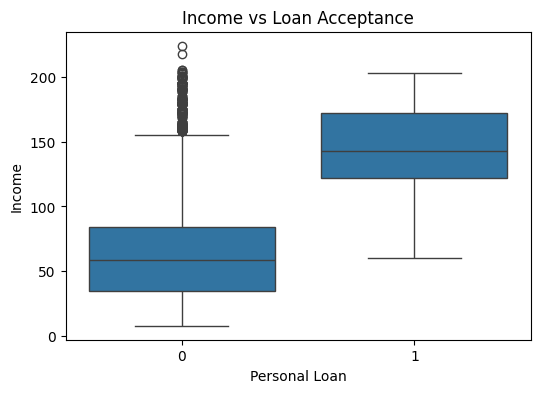

In [27]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Personal Loan", y="Income", data=data)

plt.title("Income vs Loan Acceptance")

plt.show()

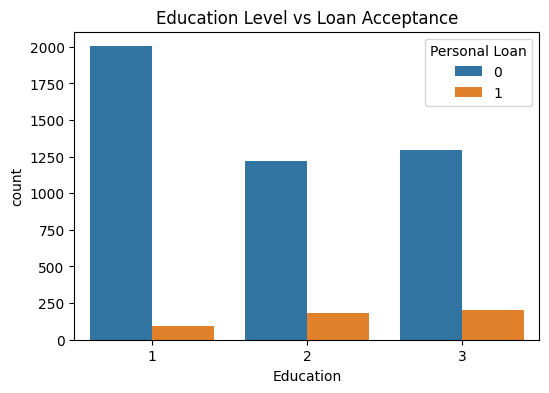

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(x="Education", hue="Personal Loan", data=data)

plt.title("Education Level vs Loan Acceptance")

plt.show()

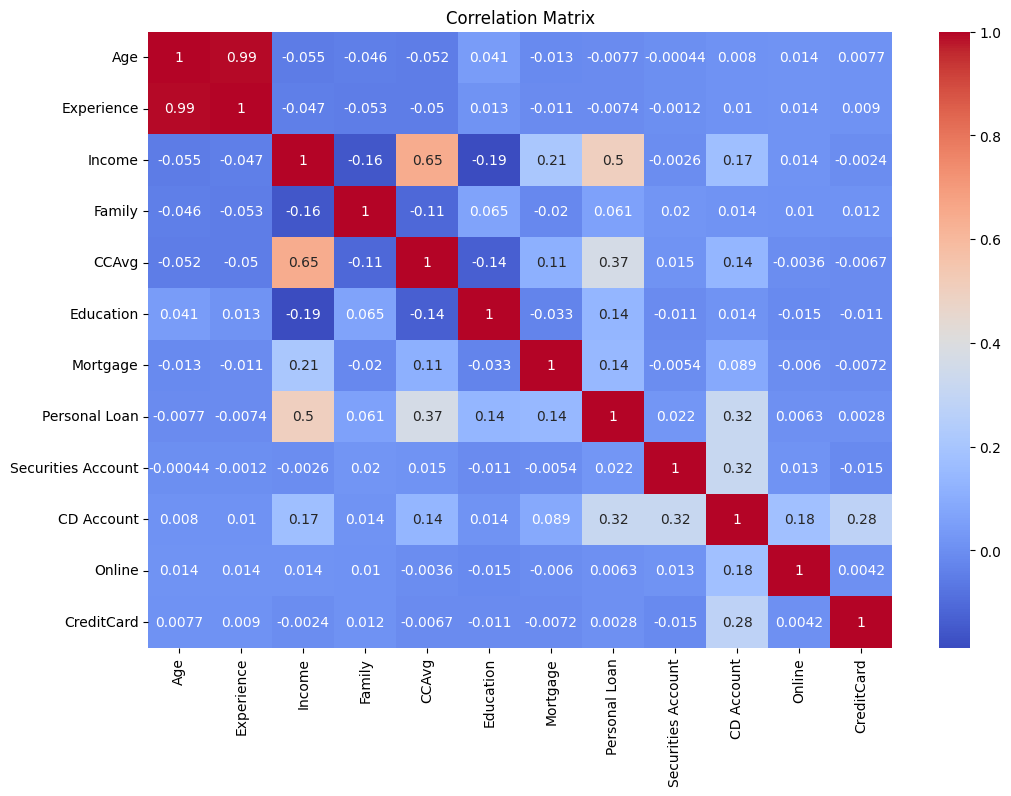

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

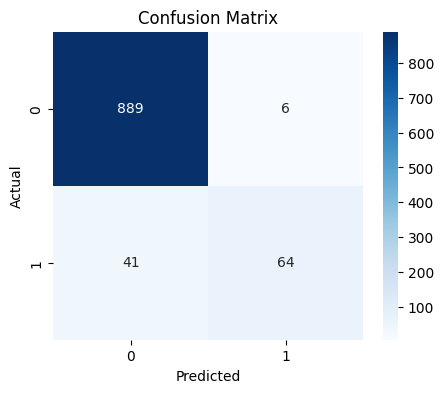

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

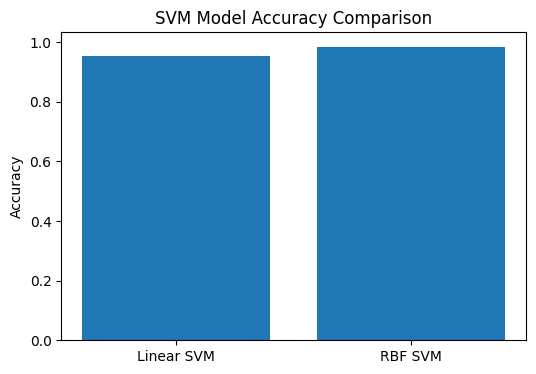

In [31]:
models = ["Linear SVM", "RBF SVM"]
scores = [accuracy, accuracy_rbf]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.title("SVM Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()